teacher AUC (asymptote) = 0.7361 | P_GRID = [8, 10, 12, 15]


C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miy\miniconda3\envs\seller_seg\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


logistic-WoE AUC = 0.7187
feature ranking: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'DAYS_REGISTRATION', 'OWN_CAR_AGE', 'FLAG_PHONE', 'DAYS_ID_PUBLISH', 'REG_CITY_NOT_WORK_CITY', 'LIVINGAREA_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'FLAG_EMP_PHONE', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'FLOORSMAX_MODE', 'FLOORSMIN_AVG', 'REG_CITY_NOT_LIVE_CITY', 'YEARS_BUILD_MODE', 'ELEVATORS_AVG', 'LIVINGAPARTMENTS_AVG']
[saved] 07_complexity_pareto.csv
frontier points (cells, AUC):
[[24.      0.7293]
 [34.      0.7315]
 [44.      0.7341]]
[saved] 07_complexity_pareto.png  &  07_complexity_pareto.pdf


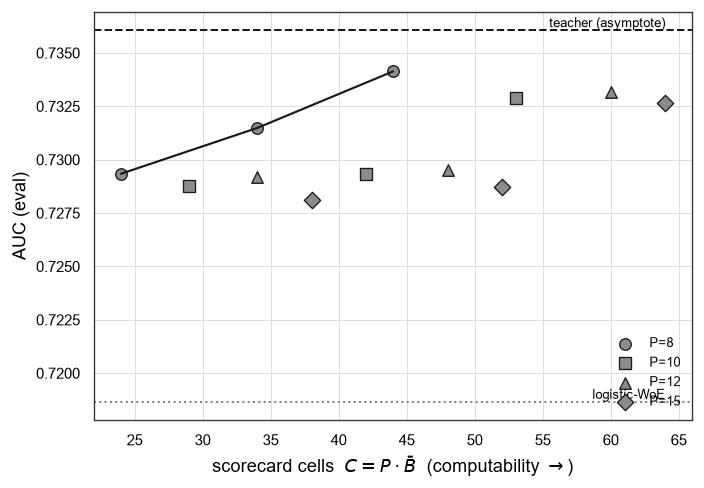

[saved] 07_loss_ledger.csv
[saved] 07_pareto_synthesis.png  &  07_pareto_synthesis.pdf


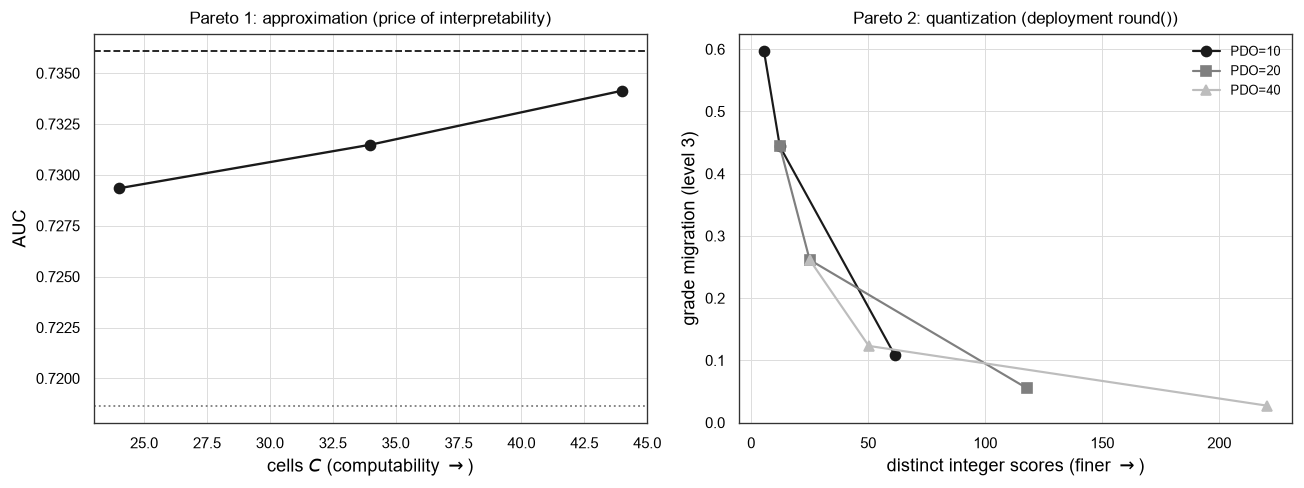

[saved] 07_results_index.csv
10 figures, 22 tables in results/


,figures (png+pdf),tables (csv+tex)
0,00_monotonicity_check.png,01_teacher_quality.csv
1,01_teacher_reliability.png,02_baseline_scorecard.csv
2,02_step_functions.png,02_lossless_verification.csv
3,03_ablation_auc.png,02_quantization_only_loss.csv
4,04_quantization_pareto.png,03_ablation_delong.csv
5,05_approved_default_rate.png,03_ablation_summary.csv
6,05_migration_heatmap.png,03_gap_recovered.csv
7,06_gate_beta_reliability.png,03_path2_crosscheck.csv
8,07_complexity_pareto.png,03_temperature_matching.csv
9,07_pareto_synthesis.png,04_quantization_levels.csv


In [1]:
# Notebook 07 — Pareto Synthesis (the price of interpretability)

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common as C
import config as CFG
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
meta = json.load(open(C.PROC_DIR / "meta.json"))
FEATURES = meta["features"]
TP = np.load(C.PROC_DIR / "teacher_probs.npz"); pT = {k: TP[k] for k in TP.files}
woe = pickle.load(open(C.PROC_DIR / "woe.pkl", "rb"))

Xtr, ytr = X.iloc[SP["train"]], y[SP["train"]]
Xes, yes = X.iloc[SP["es"]],   y[SP["es"]]
Xev, yev = X.iloc[SP["eval"]], y[SP["eval"]]
AUC_TEACHER = C.auc(yev, pT["eval"])

# P capped to available features (design values {8,10,12,15} for real data)
nfeat = len(FEATURES)
P_GRID = sorted(set(min(p, nfeat) for p in CFG.P_GRID))
B_GRID = list(CFG.B_GRID)
print("teacher AUC (asymptote) =", round(AUC_TEACHER, 4), "| P_GRID =", P_GRID)


# ----------------------------------------------------------------------------
# Anchor 1: logistic-WoE baseline (lower anchor)
# ----------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(woe["Xwoe"]["train"], ytr)
p_woe = lr.predict_proba(woe["Xwoe"]["eval"])[:, 1]
AUC_WOE = C.auc(yev, p_woe)
# feature ranking by |corr(WoE, y)| on train (monotone signal strength)
corr = {f: abs(np.corrcoef(woe["Xwoe"]["train"][:, j], ytr)[0, 1])
        for j, f in enumerate(FEATURES)}
ranked = [f for f, _ in sorted(corr.items(), key=lambda kv: -kv[1])]
print(f"logistic-WoE AUC = {AUC_WOE:.4f}")
print("feature ranking:", ranked)


# ----------------------------------------------------------------------------
# Pareto 1: sweep (P, B) for the Full pipeline (TFM-induced bins + distill)
# ----------------------------------------------------------------------------
def fit_full(features_sub, n_bins):
    binning = C.fit_binning(Xtr[features_sub], pT["train"], features_sub,
                            n_bins=n_bins, method="TFM_induced")
    Xtr_b = C.apply_binning(Xtr[features_sub], binning)
    Xes_b = C.apply_binning(Xes[features_sub], binning)
    Xev_b = C.apply_binning(Xev[features_sub], binning)
    sc = C.fit_stump_scorecard(Xtr_b, pT["train"], Xes_b, yes)
    p = sc.predict_proba(Xev_b)
    return C.auc(yev, p), sc.n_cells()

rows = []
for P in P_GRID:
    feats = ranked[:P]
    for B in B_GRID:
        auc_v, cells = fit_full(feats, B)
        rows.append({"P": P, "B": B, "cells": cells, "AUC": auc_v,
                     "approx_gap": AUC_TEACHER - auc_v})
pareto1 = pd.DataFrame(rows)
C.save_table(pareto1.round(5), "07_complexity_pareto")
pareto1.round(4)


# ----------------------------------------------------------------------------
# Pareto frontier: best AUC achievable at or below each cell budget
# ----------------------------------------------------------------------------
ps = pareto1.sort_values("cells")
frontier, best = [], -1
for _, r in ps.iterrows():
    if r["AUC"] > best:
        best = r["AUC"]; frontier.append((r["cells"], r["AUC"]))
frontier = np.array(frontier)
print("frontier points (cells, AUC):")
print(frontier.round(4))


# ----------------------------------------------------------------------------
# Figure 1: complexity-performance Pareto (grayscale) with anchors
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.0, 4.2))
_markers = ["o", "s", "^", "D", "v", "P", "*", "X"]
mk = {P: _markers[i % len(_markers)] for i, P in enumerate(P_GRID)}
for P in P_GRID:
    sub = pareto1[pareto1.P == P]
    ax.scatter(sub["cells"], sub["AUC"], marker=mk[P], s=48,
               facecolor="#8c8c8c", edgecolor="#1a1a1a", linewidth=0.8,
               label=f"P={P}")
ax.plot(frontier[:, 0], frontier[:, 1], color="#1a1a1a", linewidth=1.3,
        linestyle="-", zorder=1)
ax.axhline(AUC_TEACHER, color="#1a1a1a", linestyle="--", linewidth=1.2)
ax.text(pareto1["cells"].max(), AUC_TEACHER, " teacher (asymptote)",
        va="bottom", ha="right", fontsize=8)
ax.axhline(AUC_WOE, color="#7f7f7f", linestyle=":", linewidth=1.2)
ax.text(pareto1["cells"].max(), AUC_WOE, " logistic-WoE", va="bottom",
        ha="right", fontsize=8)
ax.set_xlabel("scorecard cells  $C = P\\cdot\\bar B$  (computability $\\rightarrow$)")
ax.set_ylabel("AUC (eval)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
C.save_fig(fig, "07_complexity_pareto")
plt.show()


# ----------------------------------------------------------------------------
# Loss decomposition table (C6 + Unit 1): approximation vs quantization
# ----------------------------------------------------------------------------
q = pd.read_csv(C.TAB_DIR / "04_quantization_sweep.csv")
qf = q[q.condition == "Full"]
# approximation loss at a representative budget: largest P, mid B
P_ref = max(P_GRID)
B_ref = 5 if 5 in B_GRID else B_GRID[len(B_GRID) // 2]
approx = float(pareto1[(pareto1.P == P_ref) & (pareto1.B == B_ref)]["approx_gap"].iloc[0])
rows = []
for _, r in qf.iterrows():
    rows.append({"PDO": r["PDO"], "grid": r["grid"],
                 "approx_loss_AUC": approx,
                 "quantization_loss_AUC": -r["dAUC"],
                 "note": "reported separately, never summed"})
ledger = pd.DataFrame(rows)
C.save_table(ledger.round(5), "07_loss_ledger")
ledger.round(5)


# ----------------------------------------------------------------------------
# Figure 2: two-panel synthesis — Pareto 1 (approximation) | Pareto 2 (quantization)
# ----------------------------------------------------------------------------
lvl = pd.read_csv(C.TAB_DIR / "04_quantization_levels.csv")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# left: approximation Pareto (frontier + teacher asymptote)
ax1.plot(frontier[:, 0], frontier[:, 1], marker="o", color="#1a1a1a",
         linewidth=1.4, markersize=6)
ax1.axhline(AUC_TEACHER, color="#1a1a1a", linestyle="--", linewidth=1.1)
ax1.axhline(AUC_WOE, color="#7f7f7f", linestyle=":", linewidth=1.1)
ax1.set_xlabel("cells $C$ (computability $\\rightarrow$)")
ax1.set_ylabel("AUC")
ax1.set_title("Pareto 1: approximation (price of interpretability)", fontsize=10)

# right: quantization Pareto (grade migration vs distinct scores)
for pdo, mk in zip([10, 20, 40], ["o", "s", "^"]):
    sub = lvl[lvl.PDO == pdo].sort_values("n_distinct")
    ax2.plot(sub["n_distinct"], sub["grade_migration"], marker=mk,
             color={10:"#1a1a1a",20:"#7f7f7f",40:"#bdbdbd"}[pdo],
             linewidth=1.3, markersize=6, label=f"PDO={pdo}")
ax2.set_xlabel("distinct integer scores (finer $\\rightarrow$)")
ax2.set_ylabel("grade migration (level 3)")
ax2.set_title("Pareto 2: quantization (deployment round())", fontsize=10)
ax2.legend(fontsize=8)
fig.tight_layout()
C.save_fig(fig, "07_pareto_synthesis")
plt.show()


# ----------------------------------------------------------------------------
# Master results index
# ----------------------------------------------------------------------------
import os
figs = sorted(f for f in os.listdir(C.FIG_DIR) if f.endswith(".png"))
tabs = sorted(f for f in os.listdir(C.TAB_DIR) if f.endswith(".csv"))
index = pd.DataFrame({"figures (png+pdf)": pd.Series(figs),
                      "tables (csv+tex)": pd.Series(tabs)})
C.save_table(index.fillna(""), "07_results_index")
print(f"{len(figs)} figures, {len(tabs)} tables in results/")
index.fillna("")